## Notebook feito por Ian Marques Breda
## Python 3.12.5 - windows 11 home
### Resultados no final do notebook!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def carregar_dados(caminho_treino, caminho_teste):
    """Carrega os datasets de treino e teste."""
    dados_treino = pd.read_csv(caminho_treino)
    dados_teste = pd.read_csv(caminho_teste)
    
    # Separa features e labels
    X_treino = dados_treino.drop('label', axis=1)
    y_treino = dados_treino['label']
    
    X_teste = dados_teste.drop('label', axis=1)
    y_teste = dados_teste['label']
    
    return X_treino, y_treino, X_teste, y_teste

# Inicializa pesos e bias aleatorios
def inicializar_parametros(n_features):
    pesos = np.random.uniform(-1, 1, n_features)
    bias = np.random.uniform(-1, 1)
    return pesos, bias

In [3]:
def calcular_acuracia(X, y, pesos, bias):
    # Calcula a acurácia do modelo nos dados fornecidos.
    acertos = 0
    total = X.shape[0]
    
    for i in range(total):
        entrada = np.dot(pesos, X.iloc[i]) + bias
        saida_prevista = 1 if entrada >= 0 else -1
        
        if saida_prevista == y.iloc[i]:
            acertos += 1
    
    return acertos, total

In [4]:
def plotar_superficie_decissao(X, y, pesos, bias):
    #Plota os pontos e a superfície de decisão.
    pontos_positivos = X[y == 1]
    pontos_negativos = X[y == -1]
    
    plt.scatter(pontos_positivos.iloc[:, 0], pontos_positivos.iloc[:, 1], color='red', label='Classe 1')
    plt.scatter(pontos_negativos.iloc[:, 0], pontos_negativos.iloc[:, 1], color='blue', label='Classe -1')
    
    # Calcula a reta de decisão (w0*x0 + w1*x1 + b = 0)
    x_vals = np.linspace(X.iloc[:, 0].min(), X.iloc[:, 0].max(), 2)
    y_vals = (-pesos[0] * x_vals - bias) / pesos[1]
    
    plt.plot(x_vals, y_vals, 'k-', label='Superfície de decisão', linewidth=2)
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    plt.title('Classificação e Superfície de Decisão')
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
def plotar_evolucao_erro(evo_emq):
    # Plota a evolução do erro ao longo das épocas.
    plt.plot(range(0, len(evo_emq)), evo_emq, 'b-s', markersize=4)
    plt.xlabel('Época')
    plt.ylabel('Erro Quadrático Médio (EMQ)')
    plt.title('Convergência do Treinamento')
    plt.grid(True)
    plt.show()

In [6]:
def treinar_modelo(X, y, pesos, bias, lr, max_epochs, tol, batch):
    evo_emq = []
    epoch_final = max_epochs

    for epoch in range(max_epochs):
        EMQ_atual = 0
        erros = []

        if batch:
            # Aprendizado por Batch
            for linha in range(X.shape[0]):
                predict = bias + np.dot(pesos, X.iloc[linha].values)
                erro = y.iloc[linha] - predict
                EMQ_atual += erro**2
                erros.append(erro)

            EMQ_atual /= 2
            erros = np.array(erros)

            # Atualização dos parâmetros
            delta_w = lr * np.dot(X.T, erros)
            delta_b = lr * np.sum(erros)

            pesos += delta_w
            bias += delta_b

        else:
            # Aprendizado por amostra
            for linha in range(X.shape[0]):
                predict = bias + np.dot(pesos, X.iloc[linha].values)
                erro = y.iloc[linha] - predict
                EMQ_atual += erro**2

                # Atualização dos pesos e bias
                delta_w = lr * X.iloc[linha].values * erro
                delta_b = lr * erro
                pesos += delta_w
                bias += delta_b

            EMQ_atual /= 2

        # Critério de parada (comparação direta entre épocas consecutivas)
        if len(evo_emq) > 0 and abs(evo_emq[-1] - EMQ_atual) < tol:
            epoch_final = epoch
            break

        evo_emq.append(EMQ_atual)

    return pesos, bias, EMQ_atual, epoch_final, evo_emq

In [13]:
# Carrega o dataset e inicializa os parâmetros
X_treino, y_treino, X_teste, y_teste = carregar_dados('train_dataset3.csv', 'test_dataset3.csv')
pesos, bias = inicializar_parametros(X_treino.shape[1])
print(f"Pesos iniciais: {pesos}\nBias inicial: {bias}")

Pesos iniciais: [ 0.20553626 -0.57533501 -0.23317396 -0.21445851 -0.97325663  0.78263288
 -0.56677308  0.52124736 -0.29674059 -0.54342866]
Bias inicial: -0.6691530842513476


In [14]:
# Treina o modelo e exibe os pesos aprendidos, bias aprendido, épocas necessárias e acurácia do modelo

pesos, bias, EMQ_final, epoch_final, evo_emq = treinar_modelo(
    X_treino, y_treino,
    pesos, bias,
    lr=0.001,
    max_epochs=200,
    tol=0.0001,  
    batch=True # Escolher batch ativado ou não
)

print(f"\nEMQ final: {EMQ_final:.4f}")
print(f"Pesos finais: {pesos}")
print(f"Bias final: {bias:.4f}")
print(f"Épocas necessárias: {epoch_final}")
acertos, total = calcular_acuracia(X_treino, y_treino, pesos, bias)
print(f"Acurácia no treino: {acertos}/{total} ({acertos/total:.2%})")

acertos, total = calcular_acuracia(X_teste, y_teste, pesos, bias)
print(f"Acurácia no teste: {acertos}/{total} ({acertos/total:.2%})")


EMQ final: 23.7349
Pesos finais: [-1.86336613e-02 -3.92659216e-02 -2.23685446e-02 -1.74472384e-02
 -5.85786575e-02  2.29599735e-04  2.64238684e-02  6.37243233e-02
 -2.45765526e-02  6.10422501e-01]
Bias final: 0.0160
Épocas necessárias: 57
Acurácia no treino: 138/147 (93.88%)
Acurácia no teste: 54/63 (85.71%)


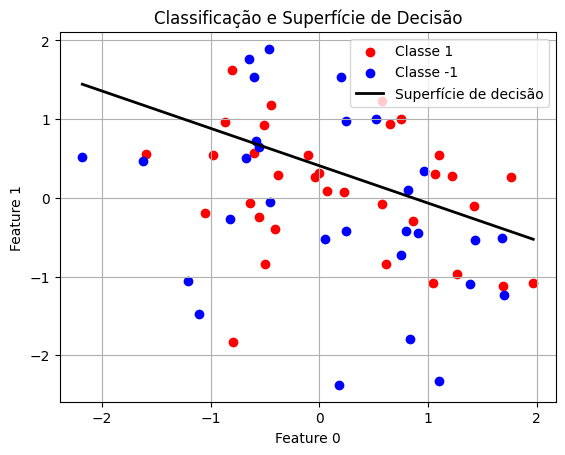

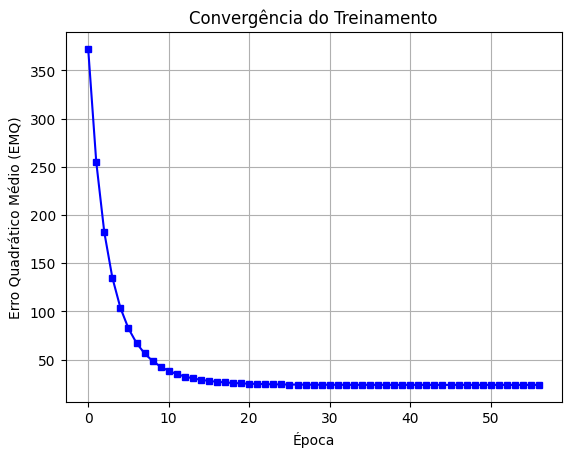

In [15]:
# Faz a plotagem da superfície aprendida e da evolução do erro
plotar_superficie_decissao(X_teste, y_teste, pesos, bias)
plotar_evolucao_erro(evo_emq)

### Dataset 1
- 2 atributos. 140 amostras de treino e 60 amostras de teste.
- numero maximo de 100 epocas,
– taxa de aprendizado igual a 0.001 e criterio de parada ε = 0.001.

- Pesos iniciais: [0.39682158 0.91057818]
- Bias inicial: -0.11877486499272516

- EMQ final: 18.5283
- Pesos finais: [-0.75226213  0.84528366]
- Bias final: 0.0094
- Épocas necessárias: 63
- Acurácia no treino: 134/140 (95.71%)
- Acurácia no teste: 57/60 (95.00%)

### Dataset 2
- 2 atributos. 175 amostras de treino e 75 amostras de teste.
- numero maximo de 100 epocas,
– taxa de aprendizado igual a 0.001 e criterio de parada ε = 0.001.

- Pesos iniciais: [ 0.3349038  -0.47968019]
- Bias inicial: 0.8864203082370676

- EMQ final: 87.2574
- Pesos finais: [-0.04617988 -0.10524465]
- Bias final: 0.0086
- Épocas necessárias: 78
- Acurácia no treino: 107/175 (61.14%)
- Acurácia no teste: 39/75 (52.00%)

### Dataset 3
- 10 atributos. 147 amostras de treino e 63 amostras de teste.
- numero maximo de 100 epocas,
– taxa de aprendizado igual a {0.001; 0.0001} e criterio de parada ε = {0.1; 0.0001}.

### taxa de aprendizado = 0.001 e criterio de parada = 0.1
- Pesos iniciais: [ 0.44252291 -0.17415776 -0.07749792 -0.66058477  0.2337969  -0.55917488 -0.51891883 -0.14257068  0.29540308 -0.29810118]
- Bias inicial: -0.04713788347954373
- EMQ final: 24.0722
- Pesos finais: [-0.00063373 -0.06514737 -0.0151525  -0.05796267 -0.07478229 -0.02581734 0.00386762  0.06220249 -0.01478581  0.60332368]
- Bias final: 0.0326
- Épocas necessárias: 20
- Acurácia no treino: 137/147 (93.20%)
- Acurácia no teste: 53/63 (84.13%)

### taxa de aprendizado = 0.001 e criterio de parada = 0.0001
- Pesos iniciais: [-0.08767706  0.41184533 -0.79193624 -0.01982959 -0.31937233 -0.05658805 -0.08339926  0.18884957 -0.33786287  0.82344454]
- Bias inicial: 0.6182535246660035
- EMQ final: 23.7349
- Pesos finais: [-0.01794302 -0.03863993 -0.02453302 -0.01711067 -0.0559315  -0.0008739 0.02799676  0.0651439  -0.02463245  0.61135603]
- Bias final: 0.0177
- Épocas necessárias: 49
- Acurácia no treino: 138/147 (93.88%)
- Acurácia no teste: 54/63 (85.71%)

### taxa de aprendizado = 0.0001 e criterio de parada = 0.1
- Pesos iniciais: [ 0.55697435 -0.03361499 -0.65993188  0.51995367 -0.78941897  0.66709178 0.73598663 -0.3796137  -0.73708988  0.25178496]
- Bias inicial: -0.029708613507792192
- EMQ final: 36.3903
- Pesos finais: [ 0.11460517 -0.03367998 -0.17766988  0.11627241 -0.16949043  0.18920594 0.22169851 -0.12062813 -0.09173954  0.57889195]
- Bias final: -0.0732
- Épocas necessárias: 100
- Acurácia no treino: 128/147 (87.07%)
- Acurácia no teste: 50/63 (79.37%)

### taxa de aprendizado = 0.0001 e criterio de parada = 0.0001
- Pesos iniciais: [ 0.70745896  0.38109097 -0.63177228 -0.80058223  0.05035445 -0.42611354 -0.28297757 -0.48429124 -0.6597309  -0.23563197]
- Bias inicial: 0.9639869763829341
- EMQ final: 37.2178
- Pesos finais: [ 0.1715826   0.00591035 -0.16422249 -0.21915033 -0.038008   -0.1329235 -0.03330868 -0.04700897 -0.0683223   0.59325987]
- Bias final: 0.2569
- Épocas necessárias: 100
- Acurácia no treino: 124/147 (84.35%)
- Acurácia no teste: 52/63 (82.54%)